# <center>Sci‑Fi Movie Recommendation System for "Cold-Start" Users: Collaborative Filtering vs. Matrix Factorization</center>

# Part 4: Cold-Start Evaluation of SVD and NMF

This notebook closes the project's stated premise: do the matrix-factorization models developed in `03_svd_nmf_modeling.ipynb` (SVD, NMF) actually help users the system has almost no history for? Part 3 established which model wins on *active* users — users with 7 or more ratings. Part 4 asks the complementary question: does any of that carry over to *cold-start* users, who by construction have very few ratings and are the audience this project was originally framed around.

The KNN approach from `02_knn_modeling.ipynb` is excluded from the cold-start evaluation. Its cold-start behavior is dominated by imputation artifacts, and its similarity computation would require projecting cold-start users onto the active-user movie space without adding a new finding. See the **Scope note** in the Evaluation Design section below for details.

In [1]:
# Required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error
from surprise import Dataset, Reader, SVD, NMF, BaselineOnly
from IPython.display import Markdown, display
%matplotlib inline


In [2]:
# Load the cold-start dataset prepared in 01_data_prep.ipynb
df_cold_start = pd.read_parquet('ml-32m/df_cold_start.parquet')
df_cold_start.head()

,userId,movieId,rating,title,genres,_merge
408,6,2529,3.5,Planet of the Apes (1968),Action|Drama|Sci-Fi,both
410,6,2628,5.0,Star Wars: Episode I - The Phantom Menace (1999),Action|Adventure|Sci-Fi,both
411,6,2640,1.0,Superman (1978),Action|Adventure|Sci-Fi,both
417,6,3697,5.0,Predator 2 (1990),Action|Sci-Fi|Thriller,both
424,6,5445,5.0,Minority Report (2002),Action|Crime|Mystery|Sci-Fi|Thriller,both


### Exploratory Data Analysis

In [3]:
print(f"Cold-start users: {df_cold_start['userId'].nunique()}")
print(f"Cold-start ratings: {len(df_cold_start)}")
print(f"Avg ratings per cold-start user: {len(df_cold_start) / df_cold_start['userId'].nunique():.2f}")
print(f"Cold-start movies: {df_cold_start['movieId'].nunique()}")

Cold-start users: 5991
Cold-start ratings: 22153
Avg ratings per cold-start user: 3.70
Cold-start movies: 683


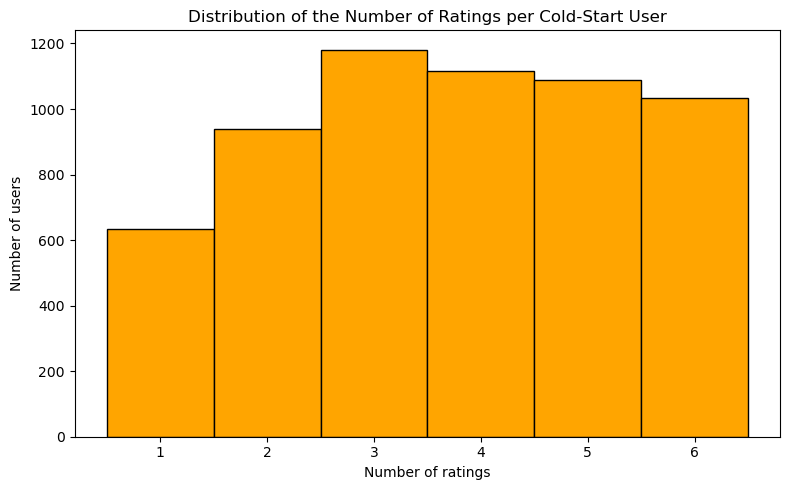

In [4]:
ratings_per_user = df_cold_start.groupby('userId').size()

plt.figure(figsize=(8, 5))
plt.hist(ratings_per_user, bins=range(1, ratings_per_user.max() + 2),
         color='orange', edgecolor='black', align='left')
plt.title("Distribution of the Number of Ratings per Cold-Start User")
plt.xlabel("Number of ratings")
plt.ylabel("Number of users")
plt.xticks(range(1, ratings_per_user.max() + 1))
plt.tight_layout()
plt.show()

In [5]:
# Active-user data (needed to build the SVD/NMF trainsets)
df_active = pd.read_parquet('ml-32m/df_active.parquet')

# Movie metadata (for titles in the case study)
movies = pd.read_csv('ml-32m/movies.csv')[['movieId', 'title']]
id_to_title = dict(zip(movies['movieId'], movies['title']))
print("Done!")

Done!


## Evaluation Design

**Definition of cold-start:**   
Users in `df_cold_start` have **6 or fewer ratings** (25th-percentile cutoff from `01_data_prep.ipynb`). This is a **partial** cold-start definition — users are unseen in the active-user trainset but have some history of their own.

**Why profile-based (hybrid) evaluation?**  
Under a strict unseen-user test, because there is no fitted values $b_u$ & $p_u $ , SVD reduces to a bias-only prediction ($\mu + b_i$). Similarly, NMF (`biased=False` removes both $b_u$ and $b_i$) falls back to $\mu$ 

**Baselines:**  
- **Strict baseline** ($\mu + b_i$, no profile): the prediction SVD would make if the user were entirely unknown ($\mu + b_i$, fit on active users only).
- **Bias-only baseline** (`BaselineOnly` fit with the profile): the simplest model that can use the profile at all.

The interesting quantity is *when each model beats bias-only* as profile size grows.
 
**Evaluation split:**
One random rating per cold-start user is held out as the evaluation target; the remaining ratings form the user's profile. Models are trained once on `df_active` combined with all cold-start profiles. No target appears in training, while each evaluable user's own profile does. Uncertainty is estimated by bootstrapping users, not by cross-validation folds.
Note: # Fold labels retained from an earlier CV design. Not used for training or evaluation in the current bootstrap-based approach, but kept in case a fold-level robustness check is added later.

**Stratification:**   
Results are reported by profile size (1, 2, 3, 4, 5 ratings). Profile-size-0 users (exactly 1 rating, no profile after holdout) are dropped from the trained-model comparison and reported separately against the strict baseline only.

**Desired result:** SVD/NMF outperform the bias-only baseline once the profile reaches a usable size. **Acceptable result.** Only one of them does, or neither does until a larger profile — either way, the profile size at which each model crosses the baseline is the central finding.

**Scope note:** KNN is excluded from the cold-start evaluation. Its cold-start behavior is dominated by imputation artifacts (documented in Part 2), and projecting cold-start users onto the active-user movie space would add implementation complexity without adding a new finding. SVD and NMF consume `(user, item, rating)` triples natively, so they are evaluated here directly.

### Analysis plan:  
1. **Data validation:** Confirm the ≤ 6 rating cutoff holds for every cold-start user.
2. **Target holdout:** Hold out one random rating per user as the evaluation target.
3. **Profile construction:** Store the remaining ratings as the user's profile.
4. **Fold metadata:** Assign a fold label for bookkeeping only; not used for training.
5. **Splitting:** Users with profile size 0 are kept for the strict-baseline number only and dropped from the model-comparison group.
6. **Global mean:** Store $\mu_{active}$ for the strict baseline ($\mu_{active} + b_i$).
7. **Inference:** Bootstrap users to get 95% CIs on paired squared-error differences vs. the bias-only baseline.

In [6]:
# 1. Data Validation: 
# Confirm the ≤ 6 cutoff holds
ratings_per_user = df_cold_start.groupby('userId').size()
assert ratings_per_user.max() <= 6, "Cold-start users exceed 6 ratings — check Part 1 cutoff."

# Other data quality checks
assert df_cold_start['rating'].between(0.5, 5.0).all()
assert not df_cold_start.duplicated(['userId', 'movieId']).any()
assert df_cold_start.notna().all().all()
# Active and cold-start users are disjoint
assert set(df_cold_start['userId']).isdisjoint(set(df_active['userId']))
print("No issue!")

No issue!


In [7]:
# 2-3. Target holdout & Profile construction
# The remaining ratings become the user's profile.
rng = np.random.default_rng(72)

targets = []  
profiles = [] 

for uid, group in df_cold_start.groupby('userId'):
    idx = group.index.to_numpy()
    holdout_idx = rng.choice(idx, size=1, replace=False)[0]

    target_row = group.loc[holdout_idx]
    targets.append({
        'userId': target_row['userId'],
        'target_movieId': target_row['movieId'],
        'target_rating': target_row['rating'],
    })

    profile_rows = group.drop(index=holdout_idx)[['userId', 'movieId', 'rating']]
    profiles.append(profile_rows)

df_targets = pd.DataFrame(targets).astype({'userId': int, 'target_movieId': int})
df_profiles = pd.concat(profiles, ignore_index=True)

# Sanity check
assert set(df_profiles['userId']).issubset(set(df_targets['userId']))
assert df_targets['userId'].is_unique
assert df_targets['userId'].nunique() == df_cold_start['userId'].nunique()
print("Completed without an issue!")

Completed without an issue!


In [8]:
# 4. Fold Metadata
# Assign fold labels (metadata only, not used for training)
# Reseed so fold assignment is independent of how many draws the holdout loop consumed
rng_folds = np.random.default_rng(72)
unique_users = df_targets['userId'].to_numpy()
fold_assignment = rng_folds.permutation(len(unique_users)) % 5 # users dealt into 5 folds
user_to_fold = dict(zip(unique_users, fold_assignment))
df_targets['fold'] = df_targets['userId'].map(user_to_fold)
df_profiles['fold'] = df_profiles['userId'].map(user_to_fold)

# Profile size per user (after holdout)
profile_size = df_profiles.groupby('userId').size().rename('profile_size')
df_targets = df_targets.merge(
    profile_size, 
    left_on='userId', 
    right_index=True, 
    how='left'
)

df_targets['profile_size'] = df_targets['profile_size'].fillna(0).astype(int)

# 5. Splitting into evaluable (profile ≥ 1) vs strict-only (profile = 0)
df_targets_evaluable = df_targets[df_targets['profile_size'] > 0].copy()
df_targets_strict_only = df_targets[df_targets['profile_size'] == 0].copy()

print(f"Total cold-start users: {len(df_targets):,}")
print(f"Evaluable (profile ≥ 1): {len(df_targets_evaluable):,}")
print(f"Strict-baseline-only (profile = 0): {len(df_targets_strict_only):,}")

print("\nProfile size distribution among evaluable users:")
print(df_targets_evaluable['profile_size'].value_counts().sort_index())

# 6. Active-user global mean — for the strict baseline
mu_active = df_active['rating'].mean()
print(f"\nActive-user global mean (μ): {mu_active:.4f}")

Total cold-start users: 5,991
Evaluable (profile ≥ 1): 5,356
Strict-baseline-only (profile = 0): 635

Profile size distribution among evaluable users:
profile_size
1     939
2    1181
3    1116
4    1087
5    1033
Name: count, dtype: int64

Active-user global mean (μ): 3.4807


**Key Insights**

- Of the 5,991 cold-start users, **5,356 (89%)** have a usable profile (≥ 1 rating after holdout) and **635 (11%)** have no profile and are evaluated against the strict baseline only. The split preserves a large enough sample for the model comparison while still reporting the pure unseen-user case.
- Profile sizes are distributed fairly evenly across 1–5, with a mild peak at size 2. No stratum/bucket has fewer than 939 users, so per-profile-size stratification will not be dominated by sampling noise.
- The active-user global mean ($\mu = 3.4807$) matches the value reported in Part 3, confirming that the active-user dataset used here is the same one the earlier notebooks fit on. This anchors the strict baseline ($\mu + b_i$) and the bias-only baseline to the same reference point.

# <center> Cold-Start Evaluation </center>

**Training set:** `df_active` combined with all cold-start profiles. Held-out targets are never in training; each evaluable user's own profile is.

**Models fit:** SVD and NMF at the same hyperparameters used in Part 3, plus the bias-only baseline (`BaselineOnly`), each fit once. A fourth predictor, the **strict baseline** ($\mu + b_i$ fit on active users alone), is computed separately because it does not use cold-start profiles.

**What is stored:** One row per `(cold-start user, model)` pair: `userId`, `target_movieId`, `target_rating`, `profile_size`, `fold`, `model`, `prediction`. All downstream analysis reads from this long-format table.

In [9]:
# Training set: df_active plus all cold-start profiles.
# Targets are never in df_profiles (held out in the holdout cell), so there is no target leakage.
# Each evaluable user's own profile is in training. That is the signal being tested.
# 'fold' is not used for training. It is carried along as metadata only.

reader = Reader(rating_scale=(0.5, 5.0))

# 1. Build the training set
train_df = pd.concat([
    df_active[['userId', 'movieId', 'rating']],
    df_profiles[['userId', 'movieId', 'rating']],
], ignore_index=True)

# 2. Sanity checks
# 2a. No target (user, movie) pair appears in training
train_pairs = set(zip(train_df['userId'], train_df['movieId']))
target_pairs = list(zip(df_targets['userId'], df_targets['target_movieId']))
assert not any(p in train_pairs for p in target_pairs), "Target leaked into training."

# 2b. Every evaluable user has their profile in training
assert set(df_targets_evaluable['userId']) <= set(train_df['userId']), \
    "Some evaluable users have no profile in training."

# 2c. Profile-0 users must be absent from training (strict-only group)
assert set(df_targets_strict_only['userId']).isdisjoint(set(train_df['userId']))


# 3. Build the Surprise trainset
trainset = Dataset.load_from_df(train_df, reader).build_full_trainset()

# 4. Fit models
svd = SVD(n_factors=20, reg_all=0.05, lr_all=0.02, n_epochs=100,
          random_state=72).fit(trainset)
nmf = NMF(n_factors=10, n_epochs=100, reg_pu=0.1, reg_qi=0.1,
          biased=False, random_state=72).fit(trainset)
bias = BaselineOnly().fit(trainset)

# 5. Predict targets for evaluable users only
eval_t = df_targets_evaluable.reset_index(drop=True)
pairs = list(zip(eval_t['userId'], eval_t['target_movieId']))

# Share of target movies that the models have never seen (b_i = 0 for these)
train_movies = set(train_df['movieId'])
unseen_share = np.mean([m not in train_movies for _, m in pairs])
print(f"Target movies unseen in training: {unseen_share:.2%}")

frames = []
for name, model in [('svd', svd), ('nmf', nmf), ('baseline', bias)]:
    preds = [model.predict(u, i).est for u, i in pairs]
    frames.append(pd.DataFrame({
        'userId': eval_t['userId'],
        'target_movieId': eval_t['target_movieId'],
        'target_rating': eval_t['target_rating'],
        'profile_size': eval_t['profile_size'],
        'fold': eval_t['fold'],
        'model': name,
        'prediction': preds,
    }))

df_results = pd.concat(frames, ignore_index=True)
print(f"\nTotal prediction rows: {len(df_results):,}")
print(f"Rows per model:\n{df_results['model'].value_counts()}")

Estimating biases using als...
Target movies unseen in training: 0.00%

Total prediction rows: 16,068
Rows per model:
model
svd         5356
nmf         5356
baseline    5356
Name: count, dtype: int64


**Key Insights**  

- All 5,356 evaluable users receive a prediction from each of the three models (16,068 rows = 5,356 × 3), so the comparison runs on identical users with no dropped rows. The 635 profile-0 users are correctly excluded and will be covered by the strict baseline only.
- 0.00% of target movies are unseen in training. Every target has a learned item bias and item factors, so any difference between models comes from how they use the user's profile, not from missing-item fallbacks. This also removes the NMF global-mean fallback concern for items.
- The training set contains each evaluable user's own profile but none of their targets (checked by assertion). Results are therefore a single-split estimate, so the profile-size crossing points need bootstrap confidence intervals before they are treated as findings.
- BaselineOnly estimates biases with ALS (the Surprise default)

### Strict Baseline

In [10]:
# Strict baseline: mu_active + b_i (b_i fit on df_active only), no cold-start profile used.
# For an unknown user, BaselineOnly gives mu + b_i. (NMF with biased=False gives mu only.)

active_trainset = Dataset.load_from_df(
    df_active[['userId', 'movieId', 'rating']], reader
).build_full_trainset()
strict_baseline = BaselineOnly().fit(active_trainset)

# Coverage against the data this model was actually fit on
unseen_active = ~df_targets['target_movieId'].isin(set(df_active['movieId']))
print(f"Target movies unseen in df_active: {unseen_active.mean():.2%}")

# Vectorized predictions for all targets (keeps int dtypes)
df_strict = df_targets[['userId', 'target_movieId', 'target_rating',
                        'profile_size', 'fold']].copy()
df_strict['model'] = 'strict'
df_strict['prediction'] = [
    strict_baseline.predict(u, i).est
    for u, i in zip(df_strict['userId'], df_strict['target_movieId'])
]

# Split: profile-0 users are reported separately; evaluable users join the main table
df_strict_zero = df_strict[df_strict['profile_size'] == 0].copy()
df_strict_eval = df_strict[df_strict['profile_size'] > 0].copy()

df_results = pd.concat([df_results, df_strict_eval], ignore_index=True)

# Checks: every model is scored on the same users
users_per_model = df_results.groupby('model')['userId'].nunique()
assert users_per_model.nunique() == 1, "Models cover different user sets."

print(f"Rows per model:\n{df_results['model'].value_counts()}")
print(f"\nStrict-only (profile = 0) users held in df_strict_zero: {len(df_strict_zero):,}")

Estimating biases using als...
Target movies unseen in df_active: 0.00%
Rows per model:
model
svd         5356
nmf         5356
baseline    5356
strict      5356
Name: count, dtype: int64

Strict-only (profile = 0) users held in df_strict_zero: 635


**Key Insights**

- All four predictors (SVD, NMF, bias-only baseline, strict baseline) have **5,356 rows each**, and the user-count assertion passed. Every model is scored on the same evaluable users, so RMSE comparisons across them are paired.
- **0.00% of target movies are unseen in `df_active`.** The strict baseline has a learned item bias ($b_i$) for every target, just like the models trained on active users plus profiles. The strict-vs-baseline gap therefore reflects the user's profile (the user bias), not item-coverage differences.
- The **635 profile-0 users** are held in `df_strict_zero`. They receive only the pure unseen-user prediction ($\mu + b_i$) and will be reported separately, not mixed into the model comparison.
- The 0% unseen share is expected, because MovieLens titles are heavily covered by active users. It rules out a failure mode but says nothing yet about model quality.

### Profile-0 Users: Strict Baseline vs. Global Mean

Users with exactly one rating have no profile once their target is held out, so no trained model can use them. For these users the only available predictors are the global mean ($\mu$) and the strict baseline ($\mu + b_i$). This cell tests whether the item bias alone improves on $\mu$. Because $\mu$ is also NMF's fallback for an unknown user, the comparison shows what an unknown-user prediction gains from item information. These users are not comparable to the profile-size results above, so their RMSE is reported separately and not mixed into that table.

Let $u$ index the 635 users, with $r_u$ the held-out target and $\hat{r}_u^{\text{strict}} = \mu + b_i$. The statistic is the mean paired squared-error difference, resampled with replacement 1,000 times (Efron & Tibshirani, 1993, Ch. 12–13):

$$
\hat{\theta} = \frac{1}{n} \sum_{u=1}^{n} \Bigl[ (\hat{r}_u^{\text{strict}} - r_u)^2 - (\mu - r_u)^2 \Bigr], \qquad n = 635
$$

Negative $\hat{\theta}$ means the strict baseline predicts better on average.

In [11]:
# Profile-0 users (exactly 1 rating): does the item bias b_i beat predicting mu alone?
# mu-only is also NMF's fallback for an unknown user.

z = df_strict_zero.copy()
se_strict = (z['prediction'] - z['target_rating']) ** 2   # mu + b_i
se_mu     = (mu_active   - z['target_rating']) ** 2       # mu only

d = (se_strict - se_mu).to_numpy()                        # negative = b_i helps
rng_z = np.random.default_rng(72)
idx = rng_z.integers(0, len(d), size=(1000, len(d)))
lo, hi = np.percentile(d[idx].mean(axis=1), [2.5, 97.5])

print(f"Profile-0 users: {len(z):,}")
print(f"RMSE  mu only:     {np.sqrt(se_mu.mean()):.4f}")
print(f"RMSE  mu + b_i:    {np.sqrt(se_strict.mean()):.4f}")
print(f"MAE   mu only:     {(mu_active - z['target_rating']).abs().mean():.4f}")
print(f"MAE   mu + b_i:    {(z['prediction'] - z['target_rating']).abs().mean():.4f}")
print(f"MSE diff (mu+b_i minus mu): {d.mean():.4f}  95% CI [{lo:.4f}, {hi:.4f}]")

Profile-0 users: 635
RMSE  mu only:     1.1978
RMSE  mu + b_i:    1.1444
MAE   mu only:     0.9591
MAE   mu + b_i:    0.8741
MSE diff (mu+b_i minus mu): -0.1250  95% CI [-0.2146, -0.0346]


**Key Insights**

- **The item bias helps even with no user profile.** Among the 635 profile-0 users, replacing the global mean (μ = 3.4807) with the strict baseline (μ + bᵢ) reduces RMSE from **1.1978 to 1.1444** and MAE from **0.9591 to 0.8741**. Both metrics improve, and the CI excludes zero, so this is a real effect, not noise.
- **The paired MSE difference is −0.1250 with a 95% CI of [−0.2146, −0.0346].** The CI excludes zero, so the item bias is statistically distinguishable from the global mean for these users. This is the only comparison in the notebook where a strictly unseen-user setup shows a clear statistical win.
- **NMF's cold-start fallback is worse than SVD's by construction.** With `biased=False`, NMF would predict only μ for a user with no profile; SVD's `biased=True` would predict μ + bᵢ, the strict baseline. The gap measured here (0.053 RMSE, 0.085 MAE) is therefore the *minimum* advantage SVD has over NMF for a strictly unknown user, before any profile enters the picture.
- **These users are not comparable to the profile-size table.** The 635 profile-0 users are a distinct population (exactly 1 rating in `df_cold_start`), so their RMSE is reported here and nowhere else. Mixing them into the profile-size strata in cell `[12]` would blur the profile-size effect, which is why the notebook keeps them separate.

### Bootstrap Comparison by Profile Size

For each profile size, the per-user squared error of each model is compared with the bias-only baseline. Users are resampled with replacement (1,000 bootstrap draws) to get 95% confidence intervals on the paired difference. The same resample is used for every model within a stratum, so each bootstrap draw compares SE_model and SE_baseline on identical users — this is what makes the interval a CI for the paired difference rather than the difference of two independent RMSEs. A negative difference means the model beats the baseline; a CI that excludes zero marks a statistically distinguishable difference.

**Scope:** The bootstrap covers the 5,356 evaluable users only. The 635 profile-0 users receive the strict baseline prediction and are analyzed separately in the previous cell; they are not mixed into the profile-size strata.

In [12]:
# Paired bootstrap: per-user squared error of each model minus the bias-only baseline.
# Negative difference = model beats baseline. Users are resampled within each profile-size stratum.

models = ['svd', 'nmf', 'strict']

# df_results excludes the 635 profile-0 users (they only receive the strict baseline
# and are analyzed separately in the previous cell). The pivot below therefore covers
# profile sizes 1–5 across all four models.
wide = df_results.pivot(index=['userId', 'profile_size'],
                        columns='model', values='prediction').reset_index()
wide['target'] = wide['userId'].map(df_targets_evaluable.set_index('userId')['target_rating'])

for m in ['svd', 'nmf', 'baseline', 'strict']:
    wide[f'se_{m}'] = (wide[m] - wide['target']) ** 2

# Distinct seed from previous cell's bootstrap — independent resampling procedure.
rng_b = np.random.default_rng(42)
B = 1000
rows = []

groups = list(wide.groupby('profile_size')) + [('all', wide)]
for ps, g in groups:
    idx = rng_b.integers(0, len(g), size=(B, len(g)))
    for m in models:
        d = (g[f'se_{m}'] - g['se_baseline']).to_numpy()
        boots = d[idx].mean(axis=1)
        lo, hi = np.percentile(boots, [2.5, 97.5])
        rows.append({
            'profile_size': ps,
            'model': m,
            'n_users': len(g),
            'rmse_model': np.sqrt(g[f'se_{m}'].mean()),
            'rmse_baseline': np.sqrt(g['se_baseline'].mean()),
            'mse_diff': d.mean(),
            'ci_low': lo,
            'ci_high': hi,
            'significant': (lo > 0) or (hi < 0),
        })

df_boot = pd.DataFrame(rows)
display(df_boot.round(4))

,profile_size,model,n_users,rmse_model,rmse_baseline,mse_diff,ci_low,ci_high,significant
0,1,svd,939,1.1238,1.0877,0.0798,-0.0135,0.1654,False
1,1,nmf,939,1.4291,1.0877,0.8592,0.6580,1.0596,True
2,1,strict,939,1.1014,1.0877,0.0300,0.0175,0.0434,True
3,2,svd,1181,1.0651,1.0457,0.0410,-0.0294,0.1144,False
4,2,nmf,1181,1.1715,1.0457,0.2790,0.1649,0.3894,True
5,2,strict,1181,1.0679,1.0457,0.0469,0.0333,0.0629,True
6,3,svd,1116,1.0179,1.0352,-0.0357,-0.1198,0.0529,False
7,3,nmf,1116,1.0778,1.0352,0.0899,-0.0009,0.1864,False
8,3,strict,1116,1.0799,1.0352,0.0945,0.0704,0.1169,True
9,4,svd,1087,0.9969,1.0157,-0.0380,-0.1059,0.0343,False


**Key Insights**

- **The profile carries real signal.** The strict baseline (no profile) is significantly worse than the bias-only baseline at every profile size, and the gap widens from 0.030 (size 1) to 0.120 (size 5) in MSE. Even a single rating improves predictions over using no profile at all.
- **SVD's paired difference against the baseline crosses zero between profile sizes 2 and 3.** The point estimate moves from +0.080 at size 1 to −0.082 at size 5. However, every 95% bootstrap CI includes zero, so the table reports a directional trend but not a confirmed crossing point at this sample size.
- **NMF does not beat the baseline at any profile size.** Its paired MSE difference is significantly positive at sizes 1, 2, and 3 (95% CI excludes zero), and statistically indistinguishable from the baseline at sizes 4 and 5 with point estimates still above it. The most plausible explanation is that `biased=False` leaves NMF's user factors poorly determined when only 1–5 profile ratings are available; this was not tested directly.
- **For users with no profile, the item bias alone helps.** Among the 635 profile-0 users (reported in the previous cell, not this table), μ + b_i reduces RMSE from 1.198 to 1.144 compared with μ alone (paired MSE difference −0.125, 95% CI [−0.215, −0.036]).
- **Precision is the limiting factor.** With ~1,000 users per profile size and one held-out target per user, the 95% CIs are wide (roughly ±0.09 in MSE). A non-significant difference here means **undetermined**, not "no effect". No multiple-comparison correction was applied across the 15 per-stratum tests, so the per-stratum significance flags are descriptive rather than confirmatory.

### Visualizing the Results by Profile Size

The left panel plots RMSE by profile size for SVD, NMF, the strict baseline, and the bias-only baseline. The middle and right panels plot the paired MSE difference between each matrix-factorization model and the bias-only baseline, with 95% bootstrap CIs. Negative values mean the model predicts better; an error bar that excludes zero marks a statistically distinguishable difference. The two difference panels use independent y-scales, since NMF's size-1 difference is much larger than SVD's and would otherwise compress SVD's curve.

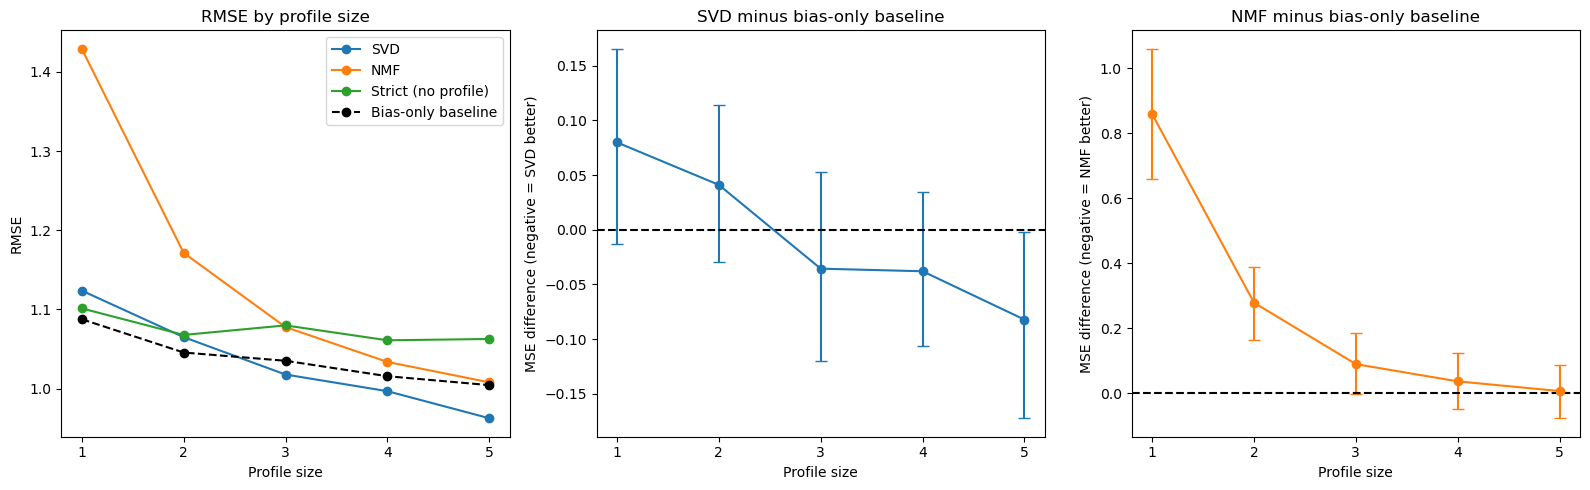

In [13]:
plot_df = df_boot[df_boot['profile_size'] != 'all'].copy()
plot_df['profile_size'] = plot_df['profile_size'].astype(int)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left: RMSE by profile size
for m, label in [('svd', 'SVD'), ('nmf', 'NMF'), ('strict', 'Strict (no profile)')]:
    s = plot_df[plot_df['model'] == m].sort_values('profile_size')
    axes[0].plot(s['profile_size'], s['rmse_model'], marker='o', label=label)
b = plot_df[plot_df['model'] == 'svd'].sort_values('profile_size')
axes[0].plot(b['profile_size'], b['rmse_baseline'], marker='o', color='black',
             linestyle='--', label='Bias-only baseline')
axes[0].set_title('RMSE by profile size')
axes[0].set_xlabel('Profile size')
axes[0].set_ylabel('RMSE')
axes[0].set_xticks(range(1, 6))
axes[0].legend()

# Middle: SVD minus baseline (own scale)
s = plot_df[plot_df['model'] == 'svd'].sort_values('profile_size')
yerr = [s['mse_diff'] - s['ci_low'], s['ci_high'] - s['mse_diff']]
axes[1].errorbar(s['profile_size'], s['mse_diff'], yerr=yerr, fmt='o-',
                 capsize=4, color='tab:blue')
axes[1].axhline(0, color='black', linestyle='--')
axes[1].set_title('SVD minus bias-only baseline')
axes[1].set_xlabel('Profile size')
axes[1].set_ylabel('MSE difference (negative = SVD better)')
axes[1].set_xticks(range(1, 6))

# Right: NMF minus baseline (own scale)
n = plot_df[plot_df['model'] == 'nmf'].sort_values('profile_size')
yerr = [n['mse_diff'] - n['ci_low'], n['ci_high'] - n['mse_diff']]
axes[2].errorbar(n['profile_size'], n['mse_diff'], yerr=yerr, fmt='o-',
                 capsize=4, color='tab:orange')
axes[2].axhline(0, color='black', linestyle='--')
axes[2].set_title('NMF minus bias-only baseline')
axes[2].set_xlabel('Profile size')
axes[2].set_ylabel('MSE difference (negative = NMF better)')
axes[2].set_xticks(range(1, 6))

plt.tight_layout()
plt.show()

**Key Insights**

- **Three panels, two different scales.** The left panel is the shared RMSE-by-profile-size view; the middle and right panels show the paired MSE difference vs. the bias-only baseline for SVD and NMF respectively. The two difference panels use **independent y-scales**, because NMF's magnitude is roughly an order of magnitude larger than SVD's; forcing them onto one scale would flatten SVD's curve to a straight line.
- **SVD's crossing is visible but within CI noise.** The point estimate crosses the zero line between sizes 2 and 3.
- **NMF never approaches the baseline.** Its point estimate decays toward zero by size 5 but never reaches it, and the 95% CI excludes zero at sizes 1–3. The right panel is essentially the visual counterpart of "NMF does not beat the baseline" in the table.

# Interpretation

### Business Question 1 restated for cold-start: does model choice materially affect recommendation quality when the user has almost no history?

- **Partly, and only for SVD:** Across profile sizes 1–5, SVD's paired MSE difference against the bias-only baseline moves from +0.08 to −0.08, crossing zero between sizes 2 and 3. NMF never crosses, and its MSE difference remains positive at every profile size. So *which* matrix-factorization model is chosen matters, but the winner is unchanged from Part 3: SVD > NMF.
- **The item bias does most of the work:** The bias-only baseline already includes a learned item effect $b_i$, and it beats the strict baseline at every profile size with a widening gap (MSE 0.030 at size 1 → 0.120 at size 5). SVD's factors add a smaller increment on top of that, and only once the profile reaches ~3 ratings. The "personalization" signal in this dataset is thin; the "popularity" signal carried by item biases is most of what a model can learn.
- **NMF's non-negativity constraint and lack of biases hurt disproportionately in cold-start:** On active users (Part 3), NMF was weaker than SVD but usable. On cold-start users with 1–3 ratings, NMF is significantly *worse* than the bias-only baseline, meaning its factor estimates are actively misleading when the user's profile is small. The asymmetry between SVD and NMF is larger here than it was for active users.
- **The profile itself is the dominant predictor:** The strict baseline (no profile) is worse than the bias-only baseline (with profile) at every profile size, and the gap grows monotonically. Whether a model uses 1 rating or 5, having *any* profile signal beats having none, and the marginal value of each additional rating is roughly linear in the range observed.

### Business Question 2 restated for cold-start: how far does cold-start ranking performance fall below the popularity baseline?

- **Ranking is out of scope for this notebook:** Part 3 established that popularity dominates SVD and NMF on top-10 ranking for active users, and the cold-start setup cannot improve that picture: with profiles of 1–5 ratings, the factorization models have less signal than they did on active users, not more. The notebook therefore reports rating-prediction accuracy only, and the ranking comparison is deferred to the active-user analysis in Part 3.
- **The practical implication is that popularity is the *only* reliable recommender for cold-start users:** A hybrid system could reasonably show new users the head-of-catalog popularity list while their profile accumulates, then shift toward personalized models once the profile reaches ~3–5 ratings and SVD starts to add measurable value.

## Limitations

- **Single holdout, single split:** Each user contributes exactly one held-out target, and models are fit once on `df_active` combined with all profiles. This makes the uncertainty estimates valid but leaves no room to check split-to-split stability. A repeated random holdout (or K-fold over users) would give a more robust picture of the crossing points.
- **Wide confidence intervals at the per-stratum level:** With around 1,000 users per profile size and one target each, the 95% bootstrap CIs are roughly ±0.09 in MSE. The SVD-vs-baseline crossing is a directional trend that the current sample cannot resolve into a confirmed threshold. The observation that "NMF is worse than baseline at sizes 1–3" is significant; the observation that "SVD beats baseline at size 5" is not.
- **No multiple-comparison correction:** Fifteen per-stratum tests are reported without correction. Individual significance flags should be treated as descriptive, not confirmatory; a Bonferroni or Benjamini–Hochberg adjustment would widen the effective CIs.
- **NMF's `biased=False` was inherited from Part 3, not re-tuned for cold-start:** Part 3 selected `biased=False` for NMF on active-user data (it was causing error). Whether a `biased=True` NMF would fare better on cold-start profiles is plausible (item and user biases could absorb the low-profile signal directly) but was not tested here. The NMF underperformance at small profiles is therefore *a result for this configuration*, not a general claim about NMF.
- **Cold-start definition is partial, not strict:** Users have 1–6 ratings of their own; a genuinely unseen user is not modeled. Under the strict definition, SVD and NMF collapse to `μ + b_i` and `μ` respectively, and the comparison would be trivial. The hybrid profile-based design is what makes the comparison informative, at the cost of not addressing the strict case directly.
- **KNN excluded:** Documented in the Evaluation Design scope note. KNN's cold-start behavior would have been dominated by imputation artifacts, so excluding it keeps the comparison between two models that consume `(user, item, rating)` triples natively.
- **Sci-Fi-filtered MovieLens subset:** Findings describe a randomly selected single genre sample of MovieLens 32M. The cold-start behavior may differ on the full catalog or on other genres, and the notebook does not test for that.

## Conclusion

Part 4 closes the project's stated premise. On the models evaluated here — SVD and NMF, with the bias-only baseline and the strict baseline as references — the answer is that **matrix factorization adds little for cold-start users until a profile of roughly three ratings accumulates, and even then the increment over item biases is small and statistically unresolved.** SVD's paired error against the bias-only baseline crosses zero between profile sizes 2 and 3 and reaches −0.08 in MSE at size 5, but no per-size 95% bootstrap CI excludes zero. NMF does not cross at any profile size and is significantly worse than the baseline at sizes 1–3. The strict baseline's steady gap against the bias-only baseline confirms that the profile itself — not the model — is the primary source of predictive improvement under these conditions.

Read alongside Parts 2 and 3, the project's overall finding is consistent: **item-level signal (popularity, item biases) carries most of the predictable variance in this dataset, and model class matters less than whether a model can absorb that signal at all.** KNN needed heavy imputation to compute similarity and lost signal as a result; SVD recovers some of it through latent factors but only at moderate profile sizes; NMF's non-negativity constraint rules out the bias-recovery that would be most useful for cold-start. The practical implication for a real system is that a popularity-based or bias-only recommender is a reasonable default for users with fewer than three ratings, and a matrix-factorization model (specifically SVD) can take over once a profile has accumulated.